Muhammad Binar Raffi Lazuardi - 2306228005 - UTS Analisis Data Tidak Terstruktur

# 🔍 Analisis Sentimen & Topic Modelling — Komentar TikTok/IG

Notebook ini melakukan:
1. **Preprocessing** teks Bahasa Indonesia
2. **Analisis Sentimen** menggunakan IndoBERT (model BERT khusus Bahasa Indonesia)
3. **Topic Modelling** menggunakan BERTopic (berbasis SBERT embeddings)
4. **Visualisasi** hasil lengkap

Dataset: `comments.csv` — 1818 komentar


## 📦 1. Instalasi Library

In [1]:
# Install semua library yang dibutuhkan
!pip install transformers torch sentence-transformers bertopic umap-learn hdbscan
!pip install pandas matplotlib seaborn wordcloud plotly scikit-learn
!pip install Sastrawi  # Stemmer Bahasa Indonesia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.4 MB/s eta 0:00:00


## 📂 2. Load & Eksplorasi Data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('comments.csv')
print(f'Total baris: {len(df)}')
print(f'Kolom: {df.columns.tolist()}')
df.head(10)

Total baris: 1818
Kolom: ['username', 'comment', 'likes']


,username,comment,likes
0,ayydeln,sekelas ui...,151963
1,06fizii,ui lagi ui lagi.. UIIAAUUIIIAAAUIIIIAA,108604
2,mojitowithberry,don't care...,0
3,zafiraaaaq,our future lawyer btw..,21827
4,aycaa__6,sekelas top 1 loh,44989
5,.hm_122,"[Sticker] padahal FH, UI lagi",30587
6,xsydle,ternyata bener yaa pendidikan tidak menentukan...,152900
7,whoopspiw,"banyak, kebetulan UI doang yg ke up",31634
8,ayaaaa4_4,fakultas hukum loh :(,45530
9,xyzaxxkaxz,ahahaha udahlah guys UI gak seindah itu,5722


In [6]:
# Statistik dasar
print('=== INFO DATASET ===')
print(df.info())
print()
print('=== MISSING VALUES ===')
print(df.isnull().sum())
print()
print('=== STATISTIK LIKES ===')
print(df['likes'].describe())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1818 entries, 0 to 1817
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   username  1818 non-null   object
 1   comment   1809 non-null   object
 2   likes     1818 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 42.7+ KB
None

=== MISSING VALUES ===
username    0
comment     9
likes       0
dtype: int64

=== STATISTIK LIKES ===
count      1818.000000
mean        402.844884
std        6155.902435
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max      152900.000000
Name: likes, dtype: float64


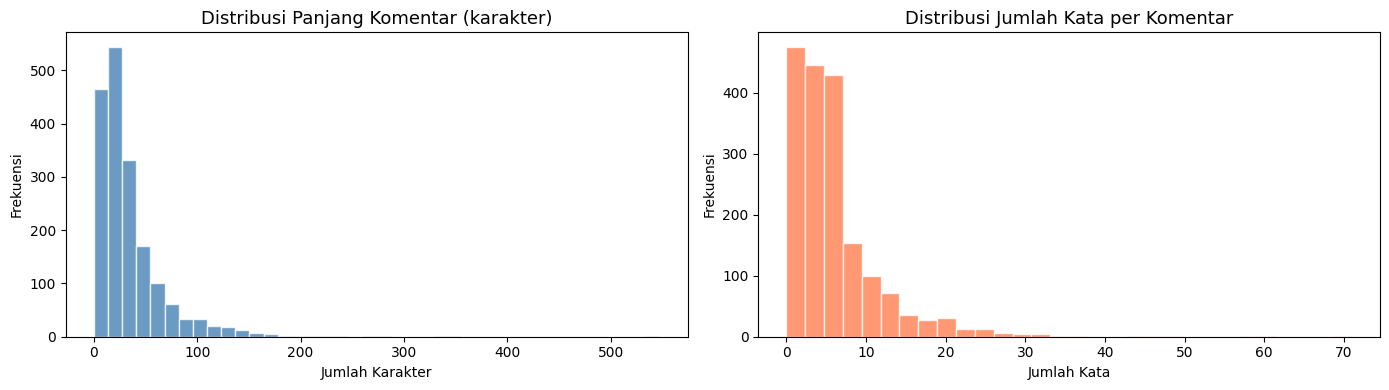

Rata-rata kata per komentar: 6.1


In [7]:
# Distribusi panjang komentar
df['comment_length'] = df['comment'].fillna('').apply(len)
df['word_count'] = df['comment'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['comment_length'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi Panjang Komentar (karakter)', fontsize=13)
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(df['word_count'], bins=30, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribusi Jumlah Kata per Komentar', fontsize=13)
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('distribusi_komentar.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Rata-rata kata per komentar: {df["word_count"].mean():.1f}')

## 🧹 3. Preprocessing Teks

In [8]:
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Inisialisasi tools Bahasa Indonesia
stop_factory = StopWordRemoverFactory()
stopwords_id = set(stop_factory.get_stop_words())

stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

# Kamus slang/singkatan umum Indonesia
slang_dict = {
    'gak': 'tidak', 'ga': 'tidak', 'g': 'tidak', 'ngga': 'tidak', 'nggak': 'tidak',
    'yg': 'yang', 'krn': 'karena', 'dgn': 'dengan', 'utk': 'untuk', 'tp': 'tapi',
    'tapi': 'tetapi', 'klo': 'kalau', 'kl': 'kalau', 'org': 'orang',
    'bgt': 'banget', 'bngt': 'banget', 'emg': 'memang', 'emang': 'memang',
    'kmrn': 'kemarin', 'skrg': 'sekarang', 'blm': 'belum', 'udh': 'sudah',
    'udah': 'sudah', 'sih': '', 'deh': '', 'dong': '', 'loh': '', 'nih': '',
    'anjir': 'astaga', 'anjing': 'astaga', 'kampus': 'universitas',
    'ui': 'universitas indonesia', 'fh': 'fakultas hukum',
    'mhs': 'mahasiswa', 'mksd': 'maksud', 'hrs': 'harus',
}

def normalize_slang(text):
    words = text.split()
    return ' '.join([slang_dict.get(w.lower(), w) for w in words])

def clean_text(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    # Hapus stiker
    text = re.sub(r'\[sticker\]', '', text)
    # Hapus URL
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Hapus mention & hashtag
    text = re.sub(r'@\w+|#\w+', '', text)
    # Hapus emoji dan karakter non-ASCII
    text = text.encode('ascii', 'ignore').decode('ascii')
    # Hapus karakter khusus kecuali spasi
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Normalisasi spasi
    text = re.sub(r'\s+', ' ', text).strip()
    # Normalisasi slang
    text = normalize_slang(text)
    return text

def preprocess_for_topic(text):
    """Preprocessing lebih dalam untuk topic modelling"""
    text = clean_text(text)
    words = text.split()
    # Hapus stopwords
    words = [w for w in words if w not in stopwords_id and len(w) > 2]
    return ' '.join(words)

# Apply preprocessing
df['text_clean'] = df['comment'].apply(clean_text)
df['text_topic'] = df['comment'].apply(preprocess_for_topic)

# Hapus komentar kosong
df = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)
print(f'Data setelah cleaning: {len(df)} baris')

# Preview hasil
pd.set_option('display.max_colwidth', 100)
df[['comment', 'text_clean', 'text_topic']].head(8)

Data setelah cleaning: 1627 baris


,comment,text_clean,text_topic
0,sekelas ui...,sekelas universitas indonesia,sekelas universitas indonesia
1,ui lagi ui lagi.. UIIAAUUIIIAAAUIIIIAA,universitas indonesia lagi universitas indonesia lagi uiiaauuiiiaaauiiiiaa,universitas indonesia universitas indonesia uiiaauuiiiaaauiiiiaa
2,don't care...,don t care,don care
3,our future lawyer btw..,our future lawyer btw,our future lawyer btw
4,sekelas top 1 loh,sekelas top,sekelas top
5,"[Sticker] padahal FH, UI lagi",padahal fakultas hukum universitas indonesia lagi,padahal fakultas hukum universitas indonesia
6,ternyata bener yaa pendidikan tidak menentukan pola pikir manusia..,ternyata bener yaa pendidikan tidak menentukan pola pikir manusia,ternyata bener yaa pendidikan menentukan pola pikir manusia
7,"banyak, kebetulan UI doang yg ke up",banyak kebetulan universitas indonesia doang yang ke up,banyak kebetulan universitas indonesia doang


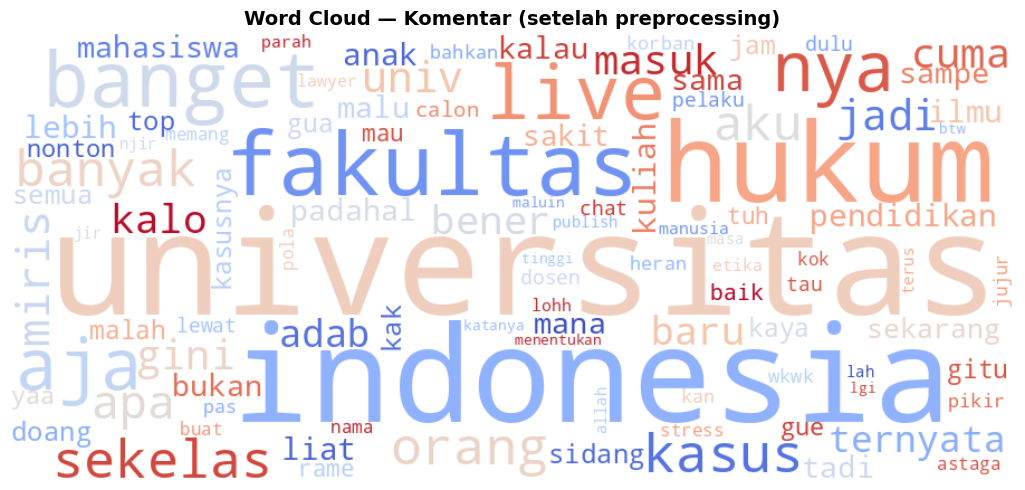

In [9]:
# WordCloud dari komentar
from wordcloud import WordCloud

all_text = ' '.join(df['text_topic'].tolist())

wc = WordCloud(
    width=900, height=400,
    background_color='white',
    colormap='coolwarm',
    max_words=100,
    collocations=False
).generate(all_text)

plt.figure(figsize=(14, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Komentar (setelah preprocessing)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

## 🤖 4. Analisis Sentimen dengan IndoBERT

Menggunakan model **`w11wo/indonesian-roberta-base-sentiment-classifier`** — model RoBERTa-based yang fine-tuned pada dataset sentimen Bahasa Indonesia (3 kelas: Positif, Negatif, Netral).

In [10]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch

print('Loading IndoBERT Sentiment model...')
print('(Download pertama kali ~500MB, tunggu sebentar)')

# Model terbaik untuk sentimen Bahasa Indonesia
MODEL_NAME = 'w11wo/indonesian-roberta-base-sentiment-classifier'

sentiment_pipeline = pipeline(
    'text-classification',
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    device=0 if torch.cuda.is_available() else -1,
    max_length=512,
    truncation=True
)

device_info = 'GPU (CUDA)' if torch.cuda.is_available() else 'CPU'
print(f'✅ Model loaded! Menggunakan: {device_info}')

Loading IndoBERT Sentiment model...
(Download pertama kali ~500MB, tunggu sebentar)


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

✅ Model loaded! Menggunakan: GPU (CUDA)


In [11]:
from tqdm.notebook import tqdm

def predict_sentiment_batch(texts, batch_size=32):
    """Predict sentimen dalam batch untuk efisiensi"""
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Prediksi Sentimen'):
        batch = texts[i:i+batch_size]
        # Truncate panjang text untuk model
        batch = [t[:512] if t else 'tidak ada komentar' for t in batch]
        preds = sentiment_pipeline(batch)
        results.extend(preds)
    return results

# Jalankan prediksi
texts = df['text_clean'].tolist()
predictions = predict_sentiment_batch(texts)

# Ekstrak label dan score
df['sentiment_label'] = [p['label'] for p in predictions]
df['sentiment_score'] = [p['score'] for p in predictions]

# Normalisasi label (pastikan konsisten)
label_map = {
    'positive': 'Positif', 'POSITIVE': 'Positif', 'pos': 'Positif',
    'negative': 'Negatif', 'NEGATIVE': 'Negatif', 'neg': 'Negatif',
    'neutral': 'Netral', 'NEUTRAL': 'Netral', 'neu': 'Netral',
}
df['sentiment'] = df['sentiment_label'].map(lambda x: label_map.get(x, x))

print('Distribusi Sentimen:')
print(df['sentiment'].value_counts())
df[['comment', 'text_clean', 'sentiment', 'sentiment_score']].head(10)

Prediksi Sentimen:   0%|          | 0/51 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Distribusi Sentimen:
sentiment
Negatif    1114
Netral      409
Positif     104
Name: count, dtype: int64


,comment,text_clean,sentiment,sentiment_score
0,sekelas ui...,sekelas universitas indonesia,Netral,0.942334
1,ui lagi ui lagi.. UIIAAUUIIIAAAUIIIIAA,universitas indonesia lagi universitas indonesia lagi uiiaauuiiiaaauiiiiaa,Negatif,0.749153
2,don't care...,don t care,Netral,0.635068
3,our future lawyer btw..,our future lawyer btw,Netral,0.691722
4,sekelas top 1 loh,sekelas top,Positif,0.423166
5,"[Sticker] padahal FH, UI lagi",padahal fakultas hukum universitas indonesia lagi,Negatif,0.668333
6,ternyata bener yaa pendidikan tidak menentukan pola pikir manusia..,ternyata bener yaa pendidikan tidak menentukan pola pikir manusia,Negatif,0.979633
7,"banyak, kebetulan UI doang yg ke up",banyak kebetulan universitas indonesia doang yang ke up,Netral,0.739007
8,fakultas hukum loh :(,fakultas hukum,Netral,0.937210
9,ahahaha udahlah guys UI gak seindah itu,ahahaha udahlah guys universitas indonesia tidak seindah itu,Negatif,0.998762


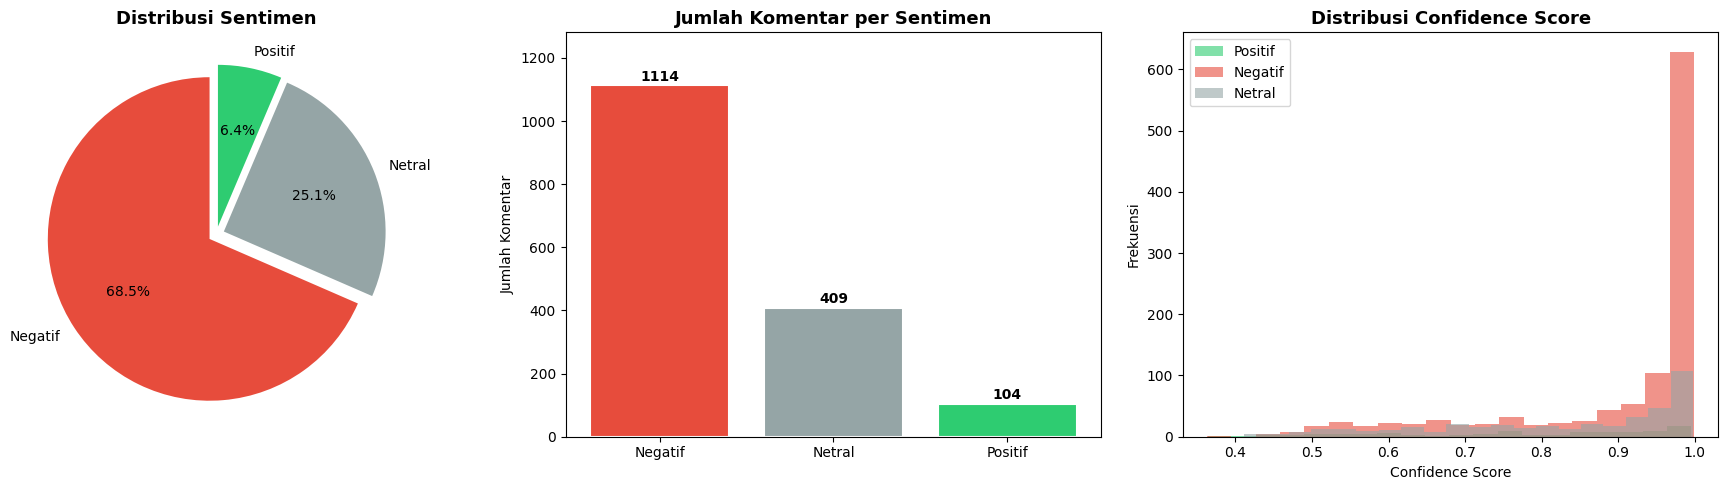

In [12]:
# === VISUALISASI SENTIMEN ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Pie Chart
sentiment_counts = df['sentiment'].value_counts()
colors = {'Positif': '#2ecc71', 'Negatif': '#e74c3c', 'Netral': '#95a5a6'}
pie_colors = [colors.get(s, '#95a5a6') for s in sentiment_counts.index]

axes[0].pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05]*len(sentiment_counts)
)
axes[0].set_title('Distribusi Sentimen', fontsize=13, fontweight='bold')

# 2. Bar Chart dengan count
bars = axes[1].bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=pie_colors,
    edgecolor='white',
    linewidth=1.5
)
for bar, val in zip(bars, sentiment_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Jumlah Komentar per Sentimen', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah Komentar')
axes[1].set_ylim(0, sentiment_counts.max() * 1.15)

# 3. Distribusi Confidence Score per Sentimen
for sent, color in colors.items():
    subset = df[df['sentiment'] == sent]['sentiment_score']
    if len(subset) > 0:
        axes[2].hist(subset, bins=20, alpha=0.6, label=sent, color=color)
axes[2].set_title('Distribusi Confidence Score', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Confidence Score')
axes[2].set_ylabel('Frekuensi')
axes[2].legend()

plt.tight_layout()
plt.savefig('analisis_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Top komentar berdasarkan likes per sentimen
print('=== TOP 5 KOMENTAR POSITIF (by likes) ===')
top_pos = df[df['sentiment']=='Positif'].nlargest(5, 'likes')[['comment','likes','sentiment_score']]
print(top_pos.to_string(index=False))

print('\n=== TOP 5 KOMENTAR NEGATIF (by likes) ===')
top_neg = df[df['sentiment']=='Negatif'].nlargest(5, 'likes')[['comment','likes','sentiment_score']]
print(top_neg.to_string(index=False))

=== TOP 5 KOMENTAR POSITIF (by likes) ===
                                                                                                                                                                                       comment  likes  sentiment_score
                                                                                                                                                                             sekelas top 1 loh  44989         0.423166
Nih buat lu yg lgi nyari kmpus buat kuliah, KUALITAS MAHASISWA TIDAK DI TENTUKAN OLEH AKREDITASI KAMPUS, so dimanapun lu kuliah ttp lah jadi orang yg berkualitas baik dalam ilmu dan adab !!!   1768         0.603362
                                                                                                                                                                ui lohh..... univ terkenal jir    733         0.814688
           real kampus itu di nilai bagus itu bukan seberapa besar nama kampus nya tapi seberapa n

=== ANALISIS LIKES PER SENTIMEN ===
           Rata-rata Likes  Median Likes  Total Likes
sentiment                                            
Negatif              351.0           1.0       390765
Netral               717.0           1.0       293211
Positif              464.0           1.0        48306


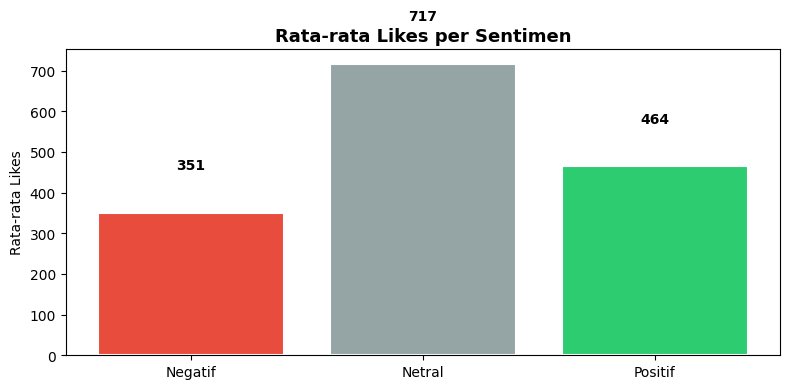

In [14]:
# Analisis: Apakah sentimen negatif lebih banyak mendapat likes?
likes_by_sentiment = df.groupby('sentiment')['likes'].agg(['mean', 'median', 'sum'])
likes_by_sentiment.columns = ['Rata-rata Likes', 'Median Likes', 'Total Likes']
print('=== ANALISIS LIKES PER SENTIMEN ===')
print(likes_by_sentiment.round(0))

fig, ax = plt.subplots(figsize=(8, 4))
sents = likes_by_sentiment.index.tolist()
avg_likes = likes_by_sentiment['Rata-rata Likes'].values
bar_colors = [colors.get(s, '#95a5a6') for s in sents]
bars = ax.bar(sents, avg_likes, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, avg_likes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,.0f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Rata-rata Likes per Sentimen', fontsize=13, fontweight='bold')
ax.set_ylabel('Rata-rata Likes')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('likes_per_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

## 🗺️ 5. Topic Modelling dengan BERTopic (SBERT Embeddings)

**BERTopic** = SBERT Embeddings + UMAP (dimensionality reduction) + HDBSCAN (clustering) + c-TF-IDF (representasi topik)

Keunggulan: menghasilkan topik yang coherent dan human-readable, mendukung bahasa Indonesia dengan multilingual SBERT.

In [27]:
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

print('Loading Multilingual SBERT model...')
# Model multilingual yang support Bahasa Indonesia
sbert_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print('✅ SBERT loaded!')

# Konfigurasi BERTopic
umap_model = UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# Vectorizer dengan stopwords Indonesia
vectorizer = CountVectorizer(
    stop_words=list(stopwords_id),
    min_df=3,
    ngram_range=(1, 2)  # unigram + bigram
)

# Inisialisasi BERTopic
topic_model = BERTopic(
    embedding_model=sbert_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    top_n_words=10,
    verbose=True,
    nr_topics='auto'  # otomatis reduce jumlah topik
)

# Gunakan text yang sudah dibersihkan
docs = df['text_clean'].tolist()

print('\nFitting BERTopic...')
topics, probs = topic_model.fit_transform(docs)

df['topic'] = topics
df['topic_prob'] = probs if probs is not None else [0]*len(docs)

print(f'\n✅ Selesai! Jumlah topik ditemukan: {len(topic_model.get_topic_info()) - 1} (di luar outlier -1)')

Loading Multilingual SBERT model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-15 17:43:12,644 - BERTopic - Embedding - Transforming documents to embeddings.


✅ SBERT loaded!

Fitting BERTopic...


Batches:   0%|          | 0/51 [00:00<?, ?it/s]

2026-04-15 17:43:13,474 - BERTopic - Embedding - Completed ✓
2026-04-15 17:43:13,476 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-15 17:43:20,148 - BERTopic - Dimensionality - Completed ✓
2026-04-15 17:43:20,149 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-15 17:43:20,234 - BERTopic - Cluster - Completed ✓
2026-04-15 17:43:20,235 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-15 17:43:20,317 - BERTopic - Representation - Completed ✓
2026-04-15 17:43:20,318 - BERTopic - Topic reduction - Reducing number of topics
2026-04-15 17:43:20,335 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-15 17:43:20,389 - BERTopic - Representation - Completed ✓
2026-04-15 17:43:20,391 - BERTopic - Topic reduction - Reduced number of topics from 56 to 16



✅ Selesai! Jumlah topik ditemukan: 15 (di luar outlier -1)


In [16]:
# Informasi topik
topic_info = topic_model.get_topic_info()
print('=== TOPIC OVERVIEW ===')
print(topic_info.to_string(index=False))

=== TOPIC OVERVIEW ===
 Topic  Count                                                   Name                                                                                              Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [17]:
# Detail kata kunci per topik
print('=== KATA KUNCI PER TOPIK ===')
for tid in sorted(topic_info['Topic'].unique()):
    if tid == -1:
        continue  # skip outlier
    words = topic_model.get_topic(tid)
    word_str = ', '.join([w[0] for w in words[:8]])
    count = topic_info[topic_info['Topic'] == tid]['Count'].values[0]
    print(f'  Topik {tid:2d} ({count:3d} dokumen): {word_str}')

=== KATA KUNCI PER TOPIK ===
  Topik  0 (493 dokumen): live, banget, nya, do, baru, liat, apa, live nya
  Topik  1 (335 dokumen): universitas, fakultas hukum, fakultas, hukum, sekelas, aja, masuk, mana
  Topik  2 (149 dokumen): hukum, fakultas hukum, fakultas, anak hukum, padahal, anak, kalo, penegak
  Topik  3 ( 70 dokumen): universitas, universitas universitas, mahasiswa, impian, kampusnya, kasus, gini, gw
  Topik  4 ( 29 dokumen): kuliah, mahasiswa, mending, nya, aja, buat, mahasiswa nya, baik
  Topik  5 ( 25 dokumen): sidang, live, nya, sampe, nonton, nya sampe, an, baru aja
  Topik  6 ( 24 dokumen): miris, miris banget, banget, miriss, sekarang, jujur, cuma mahasiswi, yaallah
  Topik  7 ( 21 dokumen): adab, ilmu, ilmu adab, lebih, tinggi, lebih tinggi, penting, bukti
  Topik  8 ( 19 dokumen): pendidikan, etika, berdampingan, sama, tdk, pentingnya, berilmu, jadi
  Topik  9 ( 17 dokumen): up, akhirnya, , , , , , 
  Topik 10 ( 15 dokumen): ketikannya, isi, chatnya, sumpah, njir, wkwk

In [41]:
# Beri nama manual pada topik (sesuaikan dengan output model Anda)
# Nama di bawah ini CONTOH — sesuaikan setelah melihat output kata kunci!
topic_names = {
    -1: 'Outlier',

    0: '[0]', #Reaksi Viral
    1: '[1]', # Ekspektasi Universitas
    2: '[2]', # Ironi Mahasiswa Hukum
    3: '[3]', # Perbandingan Kampus
    4: '[4]', # Refleksi Mahasiswa
    5: '[5]', # Pantauan Sidang
    6: '[6]', # Ekspresi Miris
    7: '[7]', # Adab vs Ilmu
    8: '[8]', # Pendidikan & Etika
    9: '[9]', # Komentar Singkat
    10: '[10]', # Reaksi Chat
    11: '[11]', # Relativisme Sosial
    12: '[12]', # Pola Pikir
    13: '[13]', # Profesi Hukum
    14: '[14]' # Emosi Intens
}
# Update nama topik di dataframe (default jika tidak ada di dict)
df['topic_name'] = df['topic'].map(lambda t: topic_names.get(t, f'Topik {t}'))

print('Contoh per topik:')
for tid in sorted(df['topic'].unique()):
    if tid == -1: continue
    sample = df[df['topic']==tid]['comment'].head(3).tolist()
    print(f'\n--- Topik {tid}: {topic_names.get(tid, f"Topik {tid}")} ---')
    for s in sample:
        print(f'  • {s[:100]}')

Contoh per topik:

--- Topik 0: [0] ---
  • don't care...
  • [Sticker] Oh, univ ini lagi. Byee
  • [Sticker] ini yg katanya "univ top 1"

--- Topik 1: [1] ---
  • sekelas ui...
  • ui lagi ui lagi.. UIIAAUUIIIAAAUIIIIAA
  • [Sticker] padahal FH, UI lagi

--- Topik 2: [2] ---
  • fakultas hukum loh :(
  • [Sticker] f-fakultas hukum..?
  • FH loh☹️🥹

--- Topik 3: [3] ---
  • [Sticker] kampus itu lagii.
  • [Sticker] kampus itu lagi....
  • real kampus itu di nilai bagus itu bukan seberapa besar nama kampus nya tapi seberapa niat dan giat 

--- Topik 4: [4] ---
  • Nih buat lu yg lgi nyari kmpus buat kuliah, KUALITAS MAHASISWA TIDAK DI TENTUKAN OLEH AKREDITASI KAM
  • itu masih mahasiswa loh, gimana kalo udah lulus dia??🥲
  • kata aku buat yang kuliah jangan menyia nyiakan kesempatan itu deh, ada loh orang yang berusaha mati

--- Topik 5: [5] ---
  • tadi live pas sidang nya lewat di beranda ku😭😭
  • barusan di atas ada live sidangnya
  • barusan liat yg lagi live sidang nya, rame jir yg

In [42]:
# Visualisasi BERTopic bawaan — Barchart per topik
fig = topic_model.visualize_barchart(top_n_topics=8, n_words=8)
fig.update_layout(title_text='Top Kata per Topik (BERTopic)', height=700)
fig.write_html('topic_barchart.html')
fig.show()

In [43]:
# Visualisasi: Topic similarity (intertopic distance)
try:
    fig2 = topic_model.visualize_topics()
    fig2.update_layout(title_text='Intertopic Distance Map')
    fig2.write_html('topic_distance.html')
    fig2.show()
except Exception as e:
    print(f'Visualisasi jarak topik tidak tersedia: {e}')

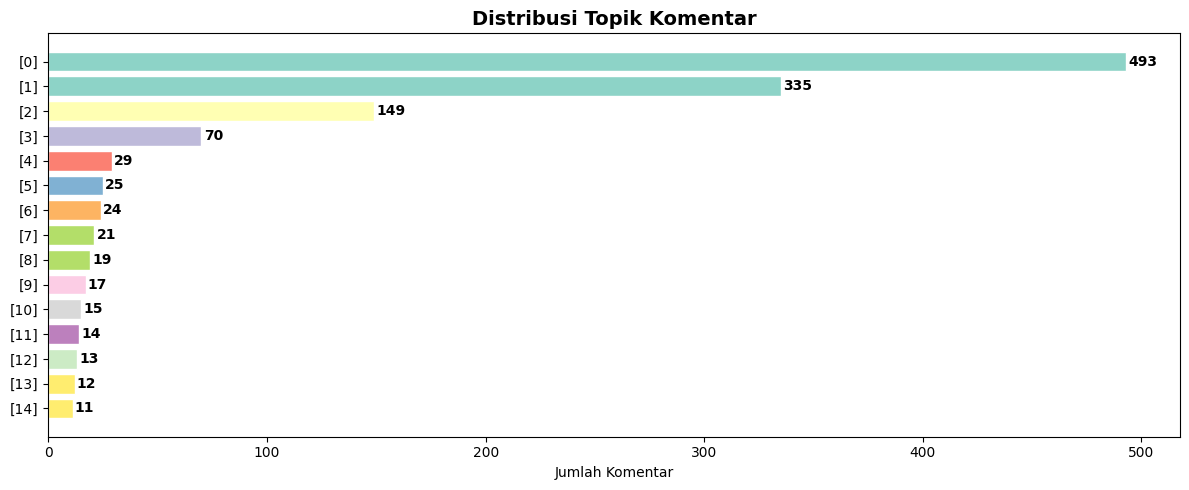

In [44]:
# Visualisasi custom: Distribusi topik
topic_dist = df[df['topic'] != -1]['topic_name'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
colors_topic = plt.cm.Set3(np.linspace(0, 1, len(topic_dist)))
bars = ax.barh(topic_dist.index, topic_dist.values, color=colors_topic, edgecolor='white')
for bar, val in zip(bars, topic_dist.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')
ax.set_title('Distribusi Topik Komentar', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Komentar')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('distribusi_topik.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔀 6. Analisis Gabungan: Sentimen × Topik

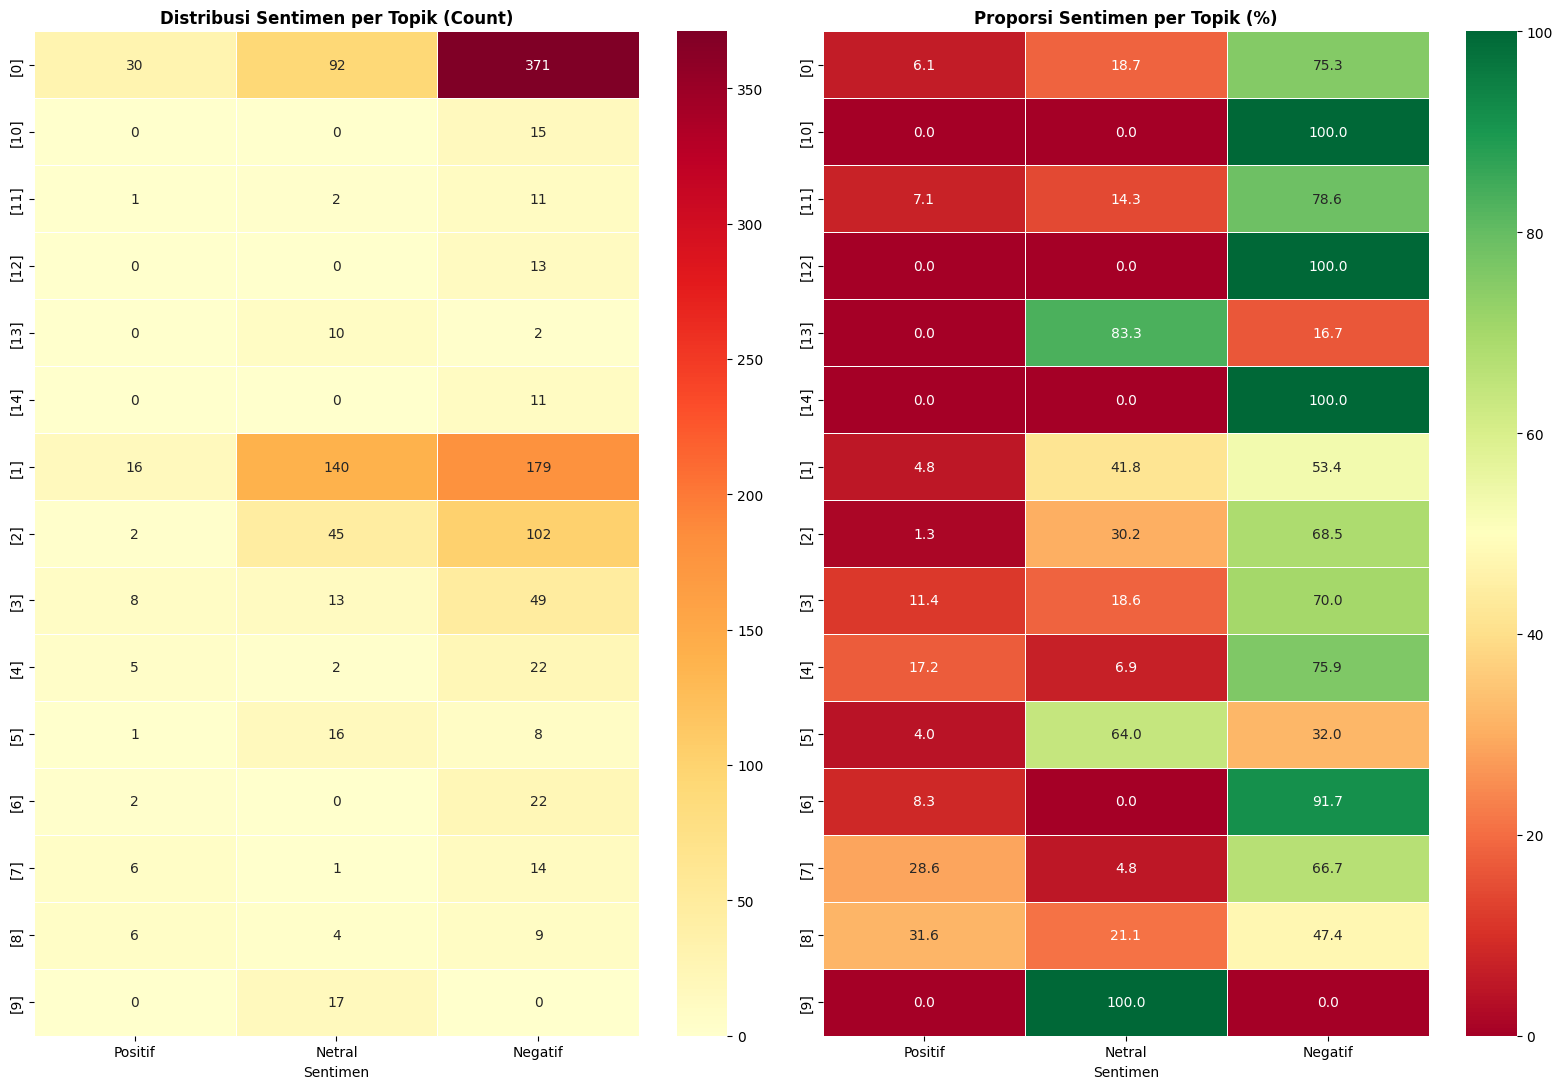

In [45]:
# Heatmap: Sentimen vs Topik
df_valid = df[df['topic'] != -1].copy()
cross_tab = pd.crosstab(df_valid['topic_name'], df_valid['sentiment'])

# Pastikan kolom ada
for col in ['Positif', 'Negatif', 'Netral']:
    if col not in cross_tab.columns:
        cross_tab[col] = 0
cross_tab = cross_tab[['Positif', 'Netral', 'Negatif']]

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(cross_tab)*0.6 + 2)))

# Heatmap count
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd',
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Distribusi Sentimen per Topik (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('')

# Heatmap proporsi
cross_pct = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100
sns.heatmap(cross_pct, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=axes[1], linewidths=0.5, vmin=0, vmax=100)
axes[1].set_title('Proporsi Sentimen per Topik (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sentimen')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('heatmap_sentimen_topik.png', dpi=150, bbox_inches='tight')
plt.show()

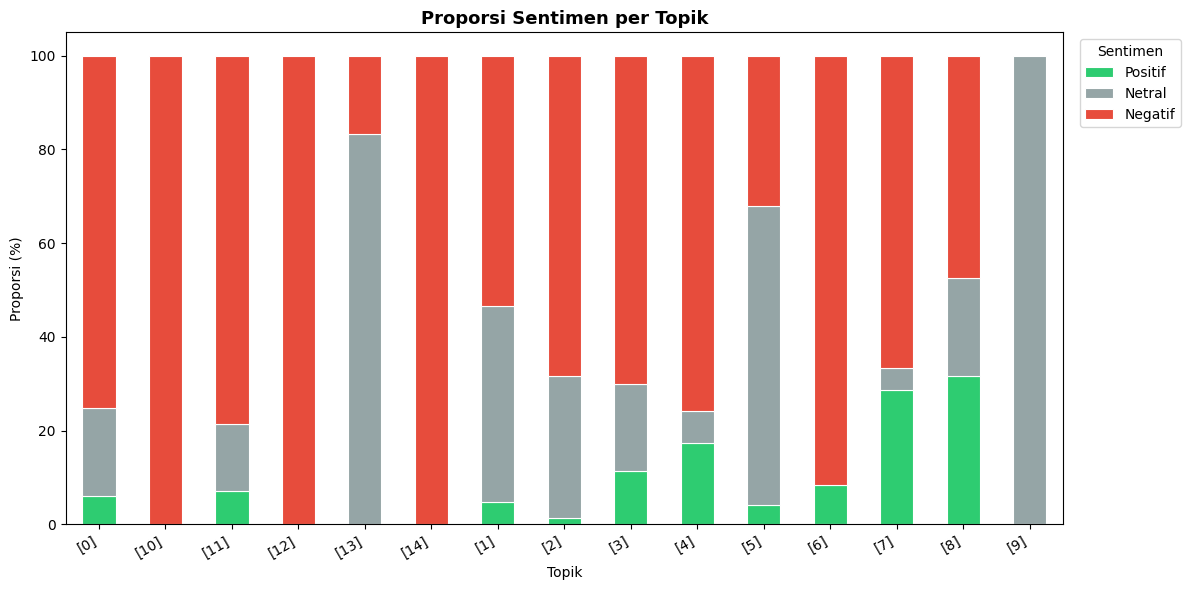

In [47]:
# Stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))
cross_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#2ecc71', '#95a5a6', '#e74c3c'],
    edgecolor='white',
    linewidth=0.8
)
ax.set_title('Proporsi Sentimen per Topik', fontsize=13, fontweight='bold')
ax.set_xlabel('Topik')
ax.set_ylabel('Proporsi (%)')
ax.legend(title='Sentimen', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('stacked_sentimen_topik.png', dpi=150, bbox_inches='tight')
plt.show()

Membuat UMAP 2D untuk visualisasi...


Batches:   0%|          | 0/26 [00:00<?, ?it/s]

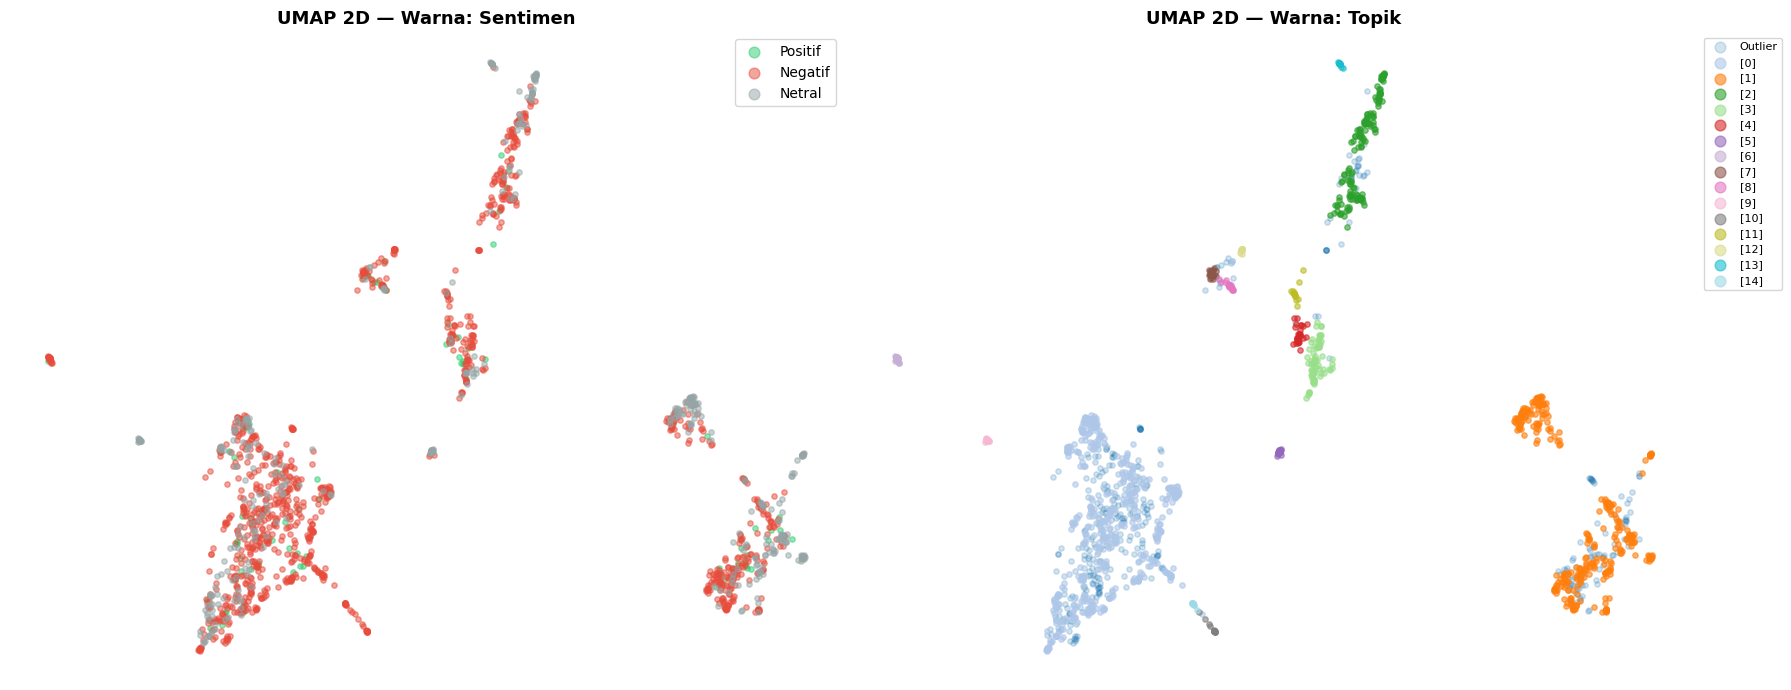

In [46]:
# UMAP 2D scatter plot: visualisasi embedding dokumen
from umap import UMAP as UMAP2D
import matplotlib.patches as mpatches

print('Membuat UMAP 2D untuk visualisasi...')
embeddings = sbert_model.encode(docs, show_progress_bar=True, batch_size=64)

umap_2d = UMAP2D(n_components=2, n_neighbors=15, min_dist=0.1,
                  metric='cosine', random_state=42)
embeddings_2d = umap_2d.fit_transform(embeddings)

df['umap_x'] = embeddings_2d[:, 0]
df['umap_y'] = embeddings_2d[:, 1]

# Plot dengan warna sentimen
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sent_colors = {'Positif': '#2ecc71', 'Negatif': '#e74c3c', 'Netral': '#95a5a6'}
for sent, color in sent_colors.items():
    mask = df['sentiment'] == sent
    axes[0].scatter(df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
                    c=color, label=sent, alpha=0.5, s=15)
axes[0].set_title('UMAP 2D — Warna: Sentimen', fontsize=13, fontweight='bold')
axes[0].legend(markerscale=2)
axes[0].axis('off')

# Plot dengan warna topik
unique_topics = sorted(df['topic'].unique())
palette = plt.cm.tab20(np.linspace(0, 1, len(unique_topics)))
for i, tid in enumerate(unique_topics):
    mask = df['topic'] == tid
    label = 'Outlier' if tid == -1 else topic_names.get(tid, f'Topik {tid}')
    alpha = 0.2 if tid == -1 else 0.6
    axes[1].scatter(df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
                    c=[palette[i]], label=label, alpha=alpha, s=15)
axes[1].set_title('UMAP 2D — Warna: Topik', fontsize=13, fontweight='bold')
axes[1].legend(markerscale=2, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('umap_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 7. Ringkasan & Insight

In [25]:
print('=' * 55)
print('          RINGKASAN ANALISIS KOMENTAR')
print('=' * 55)
print(f'Total komentar dianalisis : {len(df):,}')
print()

print('── SENTIMEN ──')
for sent, cnt in df['sentiment'].value_counts().items():
    pct = cnt/len(df)*100
    print(f'  {sent:10s}: {cnt:4d} ({pct:.1f}%)')

print()
print('── TOPIK (tanpa outlier) ──')
n_topics = len(topic_model.get_topic_info()) - 1
n_outlier = (df['topic'] == -1).sum()
print(f'  Jumlah topik   : {n_topics}')
print(f'  Dokumen outlier: {n_outlier} ({n_outlier/len(df)*100:.1f}%)')
print()
for tid in sorted(df[df['topic']!=-1]['topic'].unique()):
    cnt = (df['topic']==tid).sum()
    name = topic_names.get(tid, f'Topik {tid}')
    print(f'  Topik {tid:2d} | {cnt:3d} dok | {name}')

print()
print('── KOMENTAR PALING VIRAL ──')
top_liked = df.nlargest(3, 'likes')[['comment','likes','sentiment']]
for _, row in top_liked.iterrows():
    print(f'  [{row["sentiment"]}] {row["likes"]:,} likes — "{row["comment"][:70]}"')
print('=' * 55)

          RINGKASAN ANALISIS KOMENTAR
Total komentar dianalisis : 1,627

── SENTIMEN ──
  Negatif   : 1114 (68.5%)
  Netral    :  409 (25.1%)
  Positif   :  104 (6.4%)

── TOPIK (tanpa outlier) ──
  Jumlah topik   : 15
  Dokumen outlier: 380 (23.4%)

  Topik  0 | 493 dok | Reaksi terhadap UI/FH
  Topik  1 | 335 dok | Kualitas Mahasiswa & Universitas
  Topik  2 | 149 dok | Kasus Hukum & Moral
  Topik  3 |  70 dok | Perbandingan Kampus
  Topik  4 |  29 dok | Ekspresi Kekecewaan
  Topik  5 |  25 dok | Adab vs. Ilmu
  Topik  6 |  24 dok | Pantauan Live
  Topik  7 |  21 dok | Ekspresi Miris
  Topik  8 |  19 dok | Diskusi Grup Chat
  Topik  9 |  17 dok | Topik 9
  Topik 10 |  15 dok | Pendidikan & Etika
  Topik 11 |  14 dok | Topik 11
  Topik 12 |  13 dok | Topik 12
  Topik 13 |  12 dok | Topik 13
  Topik 14 |  11 dok | Topik 14

── KOMENTAR PALING VIRAL ──
  [Negatif] 152,900 likes — "ternyata bener yaa pendidikan tidak menentukan pola pikir manusia.."
  [Netral] 151,963 likes — "sekelas ui

## 💾 8. Ekspor Hasil

In [26]:
# Simpan hasil analisis lengkap
output_cols = ['username', 'comment', 'likes', 'text_clean',
               'sentiment', 'sentiment_score', 'topic', 'topic_name']
df_export = df[output_cols].copy()
df_export.to_csv('hasil_analisis_sentimen_topik.csv', index=False, encoding='utf-8-sig')

# Ringkasan statistik per topik
summary = df_export.groupby(['topic_name', 'sentiment']).agg(
    jumlah=('comment', 'count'),
    avg_likes=('likes', 'mean'),
    avg_confidence=('sentiment_score', 'mean')
).round(2).reset_index()
summary.to_csv('ringkasan_topik_sentimen.csv', index=False, encoding='utf-8-sig')

print('✅ File tersimpan:')
print('  • hasil_analisis_sentimen_topik.csv')
print('  • ringkasan_topik_sentimen.csv')
print('  • analisis_sentimen.png')
print('  • distribusi_topik.png')
print('  • heatmap_sentimen_topik.png')
print('  • umap_scatter.png')
print('  • topic_barchart.html (interaktif)')
print('  • topic_distance.html (interaktif)')

✅ File tersimpan:
  • hasil_analisis_sentimen_topik.csv
  • ringkasan_topik_sentimen.csv
  • analisis_sentimen.png
  • distribusi_topik.png
  • heatmap_sentimen_topik.png
  • umap_scatter.png
  • topic_barchart.html (interaktif)
  • topic_distance.html (interaktif)
